U prethodnom notebook-u analizirali smo primenu pet različitih algoritama klasterovanja nad kompletnim skupom podataka o fudbalerima, kao i nad nekoliko njegovih redukovanih verzija. Rezultati tih eksperimenata biće detaljno analizirani i vizuelizovani u narednom notebook-u.

U ovom delu rada pristup problemu je nešto drugačiji. Umesto da posmatramo sve dostupne informacije o igračima, pokušaćemo da konstruišemo skup atributa koji će biti prilagođen konkretnom cilju analize. Ideja je da zadržimo samo one informacije koje imaju najveći značaj za procenu kvaliteta igrača, dok ćemo ukloniti atribute koji mogu da uvedu šum ili da nepotrebno utiču na formiranje klastera.

Jedan od praktičnih ciljeva ovakve analize jeste identifikacija igrača koji predstavljaju najbolji odnos cene i kvaliteta. Drugim rečima, želimo da pronađemo fudbalere čije su performanse i statistički pokazatelji iznad onoga što bi se očekivalo na osnovu njihove trenutne tržišne vrednosti. Takvi igrači mogu predstavljati potencijalno isplative investicije za klubove, odnosno talente čija tržišna vrednost još uvek ne odražava njihov stvarni kvalitet.

Zbog toga ćemo u nastavku postepeno redukovati skup podataka uklanjanjem atributa za koje smatramo da nisu direktno povezani sa kvalitetom igrača (poput geografskih ili klupskih karakteristika), a zatim ćemo nad tako konstruisanim skupovima ponovo primeniti algoritme klasterovanja i uporediti dobijene rezultate.

In [2]:
import pandas as pd
from pathlib import Path

PROCESSED_DIR = Path("../data/processed")

df = pd.read_csv(
    PROCESSED_DIR / "player_features_full.csv"
)

df.shape

(44905, 105)

In [3]:
df.columns.tolist()

['player_id',
 'age',
 'height_in_cm',
 'international_caps',
 'international_goals',
 'market_value_in_eur',
 'highest_market_value_in_eur',
 'position',
 'sub_position',
 'foot',
 'country_of_birth',
 'country_of_citizenship',
 'current_club_id',
 'current_club_domestic_competition_id',
 'matches_played',
 'total_minutes',
 'avg_minutes',
 'max_minutes',
 'minutes_std',
 'total_goals',
 'total_assists',
 'total_yellow_cards',
 'total_red_cards',
 'goals_per_match',
 'assists_per_match',
 'yellow_per_match',
 'red_per_match',
 'valuation_count',
 'avg_valuation',
 'min_valuation',
 'max_valuation',
 'std_valuation',
 'first_valuation',
 'latest_valuation',
 'valuation_growth',
 'valuation_growth_pct',
 'valuation_count.1',
 'avg_valuation.1',
 'min_valuation.1',
 'max_valuation.1',
 'std_valuation.1',
 'first_valuation.1',
 'latest_valuation.1',
 'valuation_growth.1',
 'valuation_growth_pct.1',
 'transfer_count',
 'total_transfer_fee',
 'avg_transfer_fee',
 'max_transfer_fee',
 'paid_

In [10]:
original_columns_that_have_duplicates = []
duplicate_columns = []

for col in df.columns:
    if col.endswith(".1"):
        duplicate_columns.append(col)
        original_columns_that_have_duplicates.append(col)

print(duplicate_columns)

['valuation_count.1', 'avg_valuation.1', 'min_valuation.1', 'max_valuation.1', 'std_valuation.1', 'first_valuation.1', 'latest_valuation.1', 'valuation_growth.1', 'valuation_growth_pct.1']


In [5]:
df[['valuation_count.1']]

,valuation_count.1
0,23.0
1,27.0
2,28.0
3,22.0
4,31.0
...,...
44900,0.0
44901,0.0
44902,0.0
44903,0.0


In [8]:
print(sum(df['valuation_count'] == df['valuation_count.1']))

44905


In [13]:
sum(
    df[o_col].equals(df[d_col])
    for o_col, d_col in zip(original_columns_that_have_duplicates, duplicate_columns)
)

9

U prethodnim koracima smo ustanovili da je prilikom spajanja tabela doslo do ponavljanja nekih od redova, kao i da se nad redovima nisu desile nikakve promene. Zbog toga cemo sada iz skupa podataka izbaciti ponovljene kolone.

In [14]:
duplicate_columns = [
    col for col in df.columns
    if col.endswith(".1")
]

print(duplicate_columns)

['valuation_count.1', 'avg_valuation.1', 'min_valuation.1', 'max_valuation.1', 'std_valuation.1', 'first_valuation.1', 'latest_valuation.1', 'valuation_growth.1', 'valuation_growth_pct.1']


In [15]:
df = df.drop(columns=duplicate_columns)

df.shape

(44905, 96)

In [16]:
import numpy as np

from pathlib import Path
from sklearn.preprocessing import StandardScaler

PROCESSED_DIR = Path("../data/processed")
CLUSTERS_DIR = PROCESSED_DIR / "clusters"
CLUSTERS_DIR.mkdir(parents=True, exist_ok=True)

In [17]:
value_info = df[[
    "player_id",
    "market_value_in_eur",
    "highest_market_value_in_eur",
    "avg_valuation",
    "latest_valuation",
    "valuation_growth",
    "valuation_growth_pct"
]].copy()

value_info.to_csv(
    CLUSTERS_DIR / "value_for_money_reference_values.csv",
    index=False
)

Sada biramo kolone za koje smatramo da mogu biti od vaznosti za odredjivanje vrednosti fudbalera. Na osnovu svih ovih informacija cemo razdvojiti fudbalere u klastere, a zatim cemo analizirati klastere i porediti pripadnost klasteru sa njihovom trzisnom vrednoscu. Na taj nacin cemo odrediti koji igraci vrede vise nego sto im je trenutna cena.

In [19]:
pct_position_cols = [
    col for col in df.columns
    if col.startswith("pct_as_")
]

selected_columns = [
    "player_id",

    # osnovne karakteristike
    "age",
    "height_in_cm",
    "position",
    "sub_position",
    "foot",

    # iskustvo
    "international_caps",
    "international_goals",
    "matches_played",
    "total_minutes",
    "avg_minutes",
    "max_minutes",
    "minutes_std",

    # učinak
    "total_goals",
    "total_assists",
    "goals_per_match",
    "assists_per_match",

    # disciplina
    "total_yellow_cards",
    "total_red_cards",
    "yellow_per_match",
    "red_per_match",

    # uloga u timu
    "lineup_count",
    "starter_count",
    "substitute_count",
    "captain_count",
    "starter_ratio",
    "captain_ratio",

    # transferna istorija bez iznosa
    "transfer_count",
    "paid_transfer_count",
    "clubs_changed",
] + pct_position_cols

In [20]:
selected_columns = [
    col for col in selected_columns
    if col in df.columns
]

vfm_df = df[selected_columns].copy()

vfm_df.shape

(44905, 47)

In [22]:
[col for col in vfm_df.columns if "value" in col.lower() or "valuation" in col.lower()]

# Proveravamo da market_value atribut nije 'upao' u atribute koje analiziramo

[]

In [23]:
# Sada radimo One-Hot Encoding za kategoricke atribute

player_ids = vfm_df["player_id"].copy()

X_vfm_raw = vfm_df.drop(columns=["player_id"])

categorical_cols = (
    X_vfm_raw
    .select_dtypes(include=["object"])
    .columns
    .tolist()
)

categorical_cols

/tmp/ipykernel_90553/3452632119.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  .select_dtypes(include=["object"])


['position', 'sub_position', 'foot']

In [24]:
X_vfm_encoded = pd.get_dummies(
    X_vfm_raw,
    columns=categorical_cols,
    dummy_na=False
)

X_vfm_encoded.shape

(44905, 66)

In [25]:
# Proveravamo NaN vrednosti

X_vfm_encoded.isna().sum().sum()

np.int64(0)

In [26]:
# Skaliramo podatke

scaler_vfm = StandardScaler()

X_vfm = pd.DataFrame(
    scaler_vfm.fit_transform(X_vfm_encoded),
    columns=X_vfm_encoded.columns,
    index=X_vfm_encoded.index
)

X_vfm.shape

(44905, 66)

In [27]:
# Cuvamo rezultujuci skup

X_vfm.to_csv(
    CLUSTERS_DIR / "X_value_for_money.csv",
    index=False
)

pd.DataFrame({"player_id": player_ids}).to_csv(
    CLUSTERS_DIR / "player_ids_value_for_money.csv",
    index=False
)

### Klasterovanje

Sada cemo se pozabaviti najbitnijim delom ovog notebook-a, a to je klasterovanje igraca. Na osnovu prethodno vidjenih rezultata, za pocetak cemo uzeti parametre za svih 5 algoritama koji su se pokazali najbolje na prethodnim skupovima podataka. 

In [28]:
# Najpre cemo ucitati ponovo nase skupove

X_vfm = pd.read_csv(
    CLUSTERS_DIR / "X_value_for_money.csv"
).values

player_ids = pd.read_csv(
    CLUSTERS_DIR / "player_ids_value_for_money.csv"
)

print(X_vfm.shape)

(44905, 66)


In [29]:
# Za hijerarhijsko i spektralno klasterovanje ce upotreba ovako ucitanih algoritama dovesti do problema sa iskoriscenjem
# procesorskog vremena, te cemo za njih napraviti poseban skup, ogranicen na 10000 instanci

from sklearn.model_selection import train_test_split

df_meta = pd.read_csv(
    "../data/processed/player_features_full.csv"
)

sample_meta, _ = train_test_split(
    df_meta,
    train_size=10000,
    random_state=42,
    stratify=df_meta["position"]
)

sample_indices = sample_meta.index.to_numpy()

X_vfm_sample = X_vfm[sample_indices]

player_ids_sample = (
    player_ids
    .iloc[sample_indices]
    .reset_index(drop=True)
)

In [31]:
import time
import pandas as pd
import numpy as np

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

RESULTS_DIR = CLUSTERS_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


def evaluate_clustering(X, labels):
    labels = np.asarray(labels)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)

    if n_clusters < 2:
        return {
            "n_clusters": n_clusters,
            "n_noise": n_noise,
            "silhouette": np.nan,
            "davies_bouldin": np.nan,
            "calinski_harabasz": np.nan
        }

    mask = labels != -1

    return {
        "n_clusters": n_clusters,
        "n_noise": n_noise,
        "silhouette": silhouette_score(X[mask], labels[mask]),
        "davies_bouldin": davies_bouldin_score(X[mask], labels[mask]),
        "calinski_harabasz": calinski_harabasz_score(X[mask], labels[mask])
    }


def save_result(dataset_name, algorithm_name, labels, metrics):
    cluster_df = pd.DataFrame({
        "player_id": player_ids["player_id"].values,
        "cluster": labels
    })

    cluster_df.to_csv(
        RESULTS_DIR / f"{dataset_name}_{algorithm_name}_clusters.csv",
        index=False
    )

    metrics_df = pd.DataFrame([{
        "dataset": dataset_name,
        "algorithm": algorithm_name,
        **metrics
    }])

    metrics_df.to_csv(
        RESULTS_DIR / f"{dataset_name}_{algorithm_name}_metrics.csv",
        index=False
    )

    return metrics_df


def run_algorithm(X, dataset_name, algorithm_name, model):
    print(f"Running {algorithm_name} on {dataset_name}...")
    start = time.time()

    labels = model.fit_predict(X)

    elapsed = time.time() - start

    metrics = evaluate_clustering(X, labels)
    metrics["time_seconds"] = elapsed

    result = save_result(
        dataset_name,
        algorithm_name,
        labels,
        metrics
    )

    print(f"Finished {algorithm_name} on {dataset_name} in {elapsed:.2f}s")
    display(result)

    return labels, result

In [32]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, SpectralClustering
from sklearn.mixture import GaussianMixture

Kmeans

In [33]:
labels_kmeans, metrics_kmeans = run_algorithm(
    X_vfm,
    "value_for_money",
    "kmeans",
    KMeans(
        n_clusters=3,
        random_state=42,
        n_init=10
    )
)

Running kmeans on value_for_money...
Finished kmeans on value_for_money in 1.81s


,dataset,algorithm,n_clusters,n_noise,silhouette,davies_bouldin,calinski_harabasz,time_seconds
0,value_for_money,kmeans,3,0,0.07253,2.083569,3771.688921,1.809689


GMM

In [34]:
labels_gmm, metrics_gmm = run_algorithm(
    X_vfm,
    "value_for_money",
    "gmm",
    GaussianMixture(
        n_components=3,
        random_state=42,
        covariance_type="full"
    )
)

Running gmm on value_for_money...
Finished gmm on value_for_money in 9.13s


,dataset,algorithm,n_clusters,n_noise,silhouette,davies_bouldin,calinski_harabasz,time_seconds
0,value_for_money,gmm,3,0,0.055027,4.212889,1445.27431,9.134744


Hierarchical

In [35]:
player_ids_original = player_ids.copy()
player_ids = player_ids_sample.copy()

labels_hierarchical, metrics_hierarchical = run_algorithm(
    X_vfm_sample,
    "value_for_money_sample10000",
    "hierarchical",
    AgglomerativeClustering(
        n_clusters=3,
        linkage="ward"
    )
)

player_ids = player_ids_original.copy()

Running hierarchical on value_for_money_sample10000...
Finished hierarchical on value_for_money_sample10000 in 3.69s


,dataset,algorithm,n_clusters,n_noise,silhouette,davies_bouldin,calinski_harabasz,time_seconds
0,value_for_money_sample10000,hierarchical,3,0,0.079611,2.990948,606.87179,3.685462


Spectral

In [36]:
player_ids_original = player_ids.copy()
player_ids = player_ids_sample.copy()

labels_spectral, metrics_spectral = run_algorithm(
    X_vfm_sample,
    "value_for_money_sample10000",
    "spectral",
    SpectralClustering(
        n_clusters=3,
        random_state=42,
        affinity="nearest_neighbors",
        n_neighbors=10,
        assign_labels="kmeans"
    )
)

player_ids = player_ids_original.copy()

Running spectral on value_for_money_sample10000...


/home/janic/projects/ip2-football-players/venv-ip2/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:325: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


Finished spectral on value_for_money_sample10000 in 0.64s


,dataset,algorithm,n_clusters,n_noise,silhouette,davies_bouldin,calinski_harabasz,time_seconds
0,value_for_money_sample10000,spectral,3,0,0.052513,1.260364,176.080652,0.641018


DBSCAN

In [37]:
labels_dbscan, metrics_dbscan = run_algorithm(
    X_vfm,
    "value_for_money",
    "dbscan",
    DBSCAN(
        eps=2.5,
        min_samples=20,
        n_jobs=-1
    )
)

Running dbscan on value_for_money...
Finished dbscan on value_for_money in 3.52s


,dataset,algorithm,n_clusters,n_noise,silhouette,davies_bouldin,calinski_harabasz,time_seconds
0,value_for_money,dbscan,79,14726,0.193686,1.126064,1420.886448,3.516306


Na osnovu svih pokrenutih algoritama, odlucio sam se za koriscenje rezultata dobijenih KMeans algoritmom

In [39]:
analysis = df.copy()

analysis["cluster"] = labels_kmeans

analysis.head()

,player_id,age,height_in_cm,international_caps,international_goals,market_value_in_eur,highest_market_value_in_eur,position,sub_position,foot,...,event_goals,event_shootout,event_substitutions,club_squad_size,club_average_age,club_foreigners_number,club_foreigners_percentage,club_national_team_players,club_stadium_seats,cluster
0,10,48.01,184.0,0.0,0.0,1000000.0,30000000.0,Attack,Centre-Forward,right,...,62.0,0.0,67.0,28,27.6,17,60.7,11,70634,2
1,26,45.85,190.0,0.0,0.0,750000.0,8000000.0,Goalkeeper,Goalkeeper,left,...,0.0,0.0,0.0,26,26.3,14,53.8,13,81365,0
2,65,45.36,182.0,0.0,0.0,1000000.0,34500000.0,Attack,Centre-Forward,Unknown,...,38.0,0.0,35.0,31,27.8,18,58.1,9,28703,2
3,77,48.10,182.0,0.0,0.0,200000.0,24500000.0,Defender,Centre-Back,Unknown,...,0.0,0.0,1.0,25,27.3,18,72.0,19,41507,1
4,80,45.23,194.0,0.0,0.0,100000.0,3000000.0,Goalkeeper,Goalkeeper,right,...,0.0,0.0,0.0,24,27.2,12,50.0,16,75000,0


In [40]:
cluster_summary = (
    analysis
    .groupby("cluster")
    .agg({
        "age": "mean",
        "market_value_in_eur": "mean",
        "highest_market_value_in_eur": "mean",
        "matches_played": "mean",
        "total_minutes": "mean",
        "goals_per_match": "mean",
        "assists_per_match": "mean",
        "international_caps": "mean",
        "starter_ratio": "mean",
        "captain_ratio": "mean",
        "valuation_growth_pct": "mean"
    })
    .round(2)
)

cluster_summary

,age,market_value_in_eur,highest_market_value_in_eur,matches_played,total_minutes,goals_per_match,assists_per_match,international_caps,starter_ratio,captain_ratio,valuation_growth_pct
cluster,,,,,,,,,,,
0,29.73,514248.20,1094827.59,16.41,1458.27,0.00,0.00,1.34,0.24,0.01,6.64
1,28.80,792580.77,1455704.85,15.91,961.04,0.03,0.02,1.84,0.33,0.02,7.45
2,33.36,4965760.53,13065315.21,192.84,13657.70,0.11,0.08,12.83,0.66,0.07,39.30


In [41]:
analysis["cluster"].value_counts().sort_index()

cluster
0     4988
1    33461
2     6456
Name: count, dtype: int64

In [61]:
position_distribution = pd.crosstab(
    analysis["cluster"],
    analysis["position"],
    normalize="index"
).round(3)

position_distribution

position,Attack,Defender,Goalkeeper,Midfield,Missing
cluster,,,,,
0,0.000,0.000,1.000,0.000,0.000
1,0.307,0.356,0.000,0.325,0.013
2,0.291,0.371,0.026,0.312,0.000


In [63]:
cluster_summary = (
    analysis
    .groupby("cluster")
    .agg(
        player_count=("player_id", "count"),

        avg_age=("age", "mean"),
        avg_height=("height_in_cm", "mean"),

        avg_market_value=("market_value_in_eur", "mean"),
        median_market_value=("market_value_in_eur", "median"),
        avg_highest_market_value=("highest_market_value_in_eur", "mean"),

        avg_matches_played=("matches_played", "mean"),
        avg_total_minutes=("total_minutes", "mean"),
        avg_minutes_per_match=("avg_minutes", "mean"),

        avg_goals_per_match=("goals_per_match", "mean"),
        avg_assists_per_match=("assists_per_match", "mean"),

        avg_international_caps=("international_caps", "mean"),
        avg_international_goals=("international_goals", "mean"),

        avg_starter_ratio=("starter_ratio", "mean"),
        avg_captain_ratio=("captain_ratio", "mean")
    )
    .round(2)
)

cluster_summary

,player_count,avg_age,avg_height,avg_market_value,median_market_value,avg_highest_market_value,avg_matches_played,avg_total_minutes,avg_minutes_per_match,avg_goals_per_match,avg_assists_per_match,avg_international_caps,avg_international_goals,avg_starter_ratio,avg_captain_ratio
cluster,,,,,,,,,,,,,,,
0,4988,29.73,188.89,514248.20,100000.0,1094827.59,16.41,1458.27,35.97,0.00,0.00,1.34,0.00,0.24,0.01
1,33461,28.80,181.09,792580.77,200000.0,1455704.85,15.91,961.04,29.75,0.03,0.02,1.84,0.18,0.33,0.02
2,6456,33.36,182.01,4965760.53,800000.0,13065315.21,192.84,13657.70,69.94,0.11,0.08,12.83,1.70,0.66,0.07


In [64]:
cluster_summary_display = cluster_summary.copy()

cluster_summary_display["avg_market_value_millions"] = (
    cluster_summary_display["avg_market_value"] / 1_000_000
).round(2)

cluster_summary_display["median_market_value_millions"] = (
    cluster_summary_display["median_market_value"] / 1_000_000
).round(2)

cluster_summary_display["avg_highest_market_value_millions"] = (
    cluster_summary_display["avg_highest_market_value"] / 1_000_000
).round(2)

cluster_summary_display = cluster_summary_display.drop(
    columns=[
        "avg_market_value",
        "median_market_value",
        "avg_highest_market_value"
    ]
)

cluster_summary_display

,player_count,avg_age,avg_height,avg_matches_played,avg_total_minutes,avg_minutes_per_match,avg_goals_per_match,avg_assists_per_match,avg_international_caps,avg_international_goals,avg_starter_ratio,avg_captain_ratio,avg_market_value_millions,median_market_value_millions,avg_highest_market_value_millions
cluster,,,,,,,,,,,,,,,
0,4988,29.73,188.89,16.41,1458.27,35.97,0.00,0.00,1.34,0.00,0.24,0.01,0.51,0.1,1.09
1,33461,28.80,181.09,15.91,961.04,29.75,0.03,0.02,1.84,0.18,0.33,0.02,0.79,0.2,1.46
2,6456,33.36,182.01,192.84,13657.70,69.94,0.11,0.08,12.83,1.70,0.66,0.07,4.97,0.8,13.07


In [65]:
cluster_names = {
    0: "Golmani",
    1: "Igrači sa manjom minutažom",
    2: "Afirmisani igrači"
}

cluster_summary_display = cluster_summary_display.rename(
    index=cluster_names
)

cluster_summary_display

,player_count,avg_age,avg_height,avg_matches_played,avg_total_minutes,avg_minutes_per_match,avg_goals_per_match,avg_assists_per_match,avg_international_caps,avg_international_goals,avg_starter_ratio,avg_captain_ratio,avg_market_value_millions,median_market_value_millions,avg_highest_market_value_millions
cluster,,,,,,,,,,,,,,,
Golmani,4988,29.73,188.89,16.41,1458.27,35.97,0.00,0.00,1.34,0.00,0.24,0.01,0.51,0.1,1.09
Igrači sa manjom minutažom,33461,28.80,181.09,15.91,961.04,29.75,0.03,0.02,1.84,0.18,0.33,0.02,0.79,0.2,1.46
Afirmisani igrači,6456,33.36,182.01,192.84,13657.70,69.94,0.11,0.08,12.83,1.70,0.66,0.07,4.97,0.8,13.07


In [66]:
analysis["cluster_name"] = (
    analysis["cluster"]
    .map(cluster_names)
)

Sada kada smo videli kako nam izgledaju svi klasteri, za svaki od njih cemo pokusati da pronadjemo igrace cija je vrednost veca od zvanicne i u koje moze biti vredno investirati

### Golmani

Prvi na redu su nam golmani, koji cine prvi (odnosno nulti) klaster

In [68]:
goalkeepers = analysis[
    analysis["cluster"] == 0
].copy()

goalkeepers.shape

(4988, 99)

In [69]:
goalkeepers[
    [
        "market_value_in_eur",
        "age",
        "international_caps",
        "matches_played",
        "total_minutes",
        "starter_ratio"
    ]
].describe().round(2)

,market_value_in_eur,age,international_caps,matches_played,total_minutes,starter_ratio
count,4988.00,4988.00,4988.00,4988.00,4988.00,4988.00
mean,514248.20,29.73,1.34,16.41,1458.27,0.24
std,2139979.54,7.51,5.91,37.40,3344.33,0.30
min,0.00,16.65,0.00,0.00,0.00,0.00
25%,50000.00,23.87,0.00,0.00,0.00,0.00
50%,100000.00,28.52,0.00,0.00,0.00,0.10
75%,300000.00,34.20,0.00,11.00,904.75,0.42
max,40000000.00,57.86,124.00,284.00,25482.00,1.00


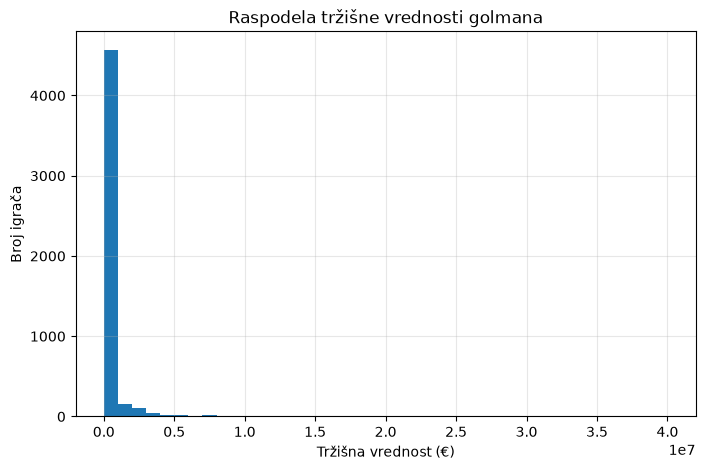

In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    goalkeepers["market_value_in_eur"],
    bins=40
)

plt.xlabel("Tržišna vrednost (€)")
plt.ylabel("Broj igrača")
plt.title("Raspodela tržišne vrednosti golmana")

plt.grid(alpha=0.3)

plt.show()

/tmp/ipykernel_90553/2142012540.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


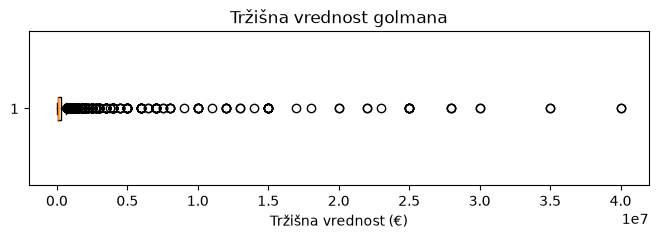

In [71]:
plt.figure(figsize=(8,2))

plt.boxplot(
    goalkeepers["market_value_in_eur"],
    vert=False
)

plt.xlabel("Tržišna vrednost (€)")
plt.title("Tržišna vrednost golmana")

plt.show()

In [72]:
q1 = goalkeepers["market_value_in_eur"].quantile(0.25)

print(f"Q1 = {q1:,.0f} €")

Q1 = 50,000 €


In [91]:
vfm_goalkeepers = goalkeepers[
    (goalkeepers["age"] <= 30) &
    (goalkeepers["market_value_in_eur"] > 0) &
    (goalkeepers["matches_played"] >= 30) &
    (goalkeepers["total_minutes"] >= 2000)
].copy()

vfm_goalkeepers.shape

(199, 99)

In [92]:
vfm_goalkeepers = vfm_goalkeepers.sort_values(
    by=[
        "valuation_growth_pct",
        "international_caps",
        "total_minutes"
    ],
    ascending=False
)

In [93]:
players = pd.read_csv("../data/processed/players_clean.csv")

In [94]:
vfm_goalkeepers = vfm_goalkeepers.merge(
    players[["player_id", "name"]],
    on="player_id",
    how="left"
)

In [95]:
vfm_goalkeepers[
    [
        "name",
        "age",
        "market_value_in_eur",
        "highest_market_value_in_eur",
        "international_caps",
        "matches_played",
        "total_minutes",
        "starter_ratio",
        "valuation_growth_pct"
    ]
].head(20)

,name,age,market_value_in_eur,highest_market_value_in_eur,international_caps,matches_played,total_minutes,starter_ratio,valuation_growth_pct
0,Bart Verbruggen,23.82,40000000.0,40000000.0,27.0,115.0,10410.0,0.500000,1599.000000
1,Giorgi Mamardashvili,25.70,28000000.0,45000000.0,37.0,147.0,13177.0,0.808989,1119.000000
2,Noah Atubolu,24.05,20000000.0,20000000.0,22.0,113.0,10153.0,0.770642,799.000000
3,Joan García,25.11,40000000.0,40000000.0,0.0,82.0,7329.0,0.529801,799.000000
4,Guglielmo Vicario,29.68,23000000.0,35000000.0,5.0,194.0,17467.0,0.790476,459.000000
5,Zion Suzuki,23.81,20000000.0,20000000.0,22.0,74.0,6645.0,0.984615,399.000000
6,Berke Özer,26.05,10000000.0,10000000.0,2.0,95.0,8413.0,0.574074,399.000000
7,Robin Roefs,23.40,25000000.0,25000000.0,0.0,71.0,6389.0,0.340909,332.333333
8,Julen Agirrezabala,25.46,15000000.0,15000000.0,8.0,84.0,7488.0,0.446927,299.000000
9,Senne Lammens,23.93,30000000.0,30000000.0,2.0,63.0,5657.0,0.253425,299.000000


Na osnovu uradjenih tehnika istrazivanja podataka, uspeli smo da izvdojimo nekoliko odlicnih golmanskih kandidata. Na osnovu ovih rezultata ne moze se reci definitivno da je recimo Noah Atubolu bolji golman od recimo Ziona Suzukija, vec recimo da smo mi skauting odeljenje jednog kluba, nas izbor bi dalje zavisio od taktike, budzeta i ostalih parametara. No, ova lista bi trebalo da da odgovor na pitanje koji kandidati potencijalno dolaze u obzir, sto je i poenta analize. Nadalje, pokusacemo u klasteru broj 1 da pronadjemo neke mlade talente koji takodje mogu predstavljati dobre investicije za klub.

### Srednji klaster

Ovaj klaster se sastoji od raznih veterana, igraca koji su vecinu karijere proveli u slabijim ligama, ali i od mladih igraca koji mogu predstavljati potencijalno dobru investiciju i igrace sa visokim potencijalom koji i dalje nisu prepoznati od strane najboljih klubova. Analiza ovog klastera ce se upravo posvetiti pronalazenju ove poslednje grupe igraca.

In [96]:
young_players = analysis[
    (analysis["cluster"] == 1) &
    (analysis["age"] <= 22)
].copy()

young_players.shape

(5484, 99)

In [97]:
young_players = young_players[
    (young_players["market_value_in_eur"] > 0) &
    (young_players["matches_played"] >= 20) &
    (young_players["total_minutes"] >= 1000)
].copy()

young_players.shape

(403, 99)

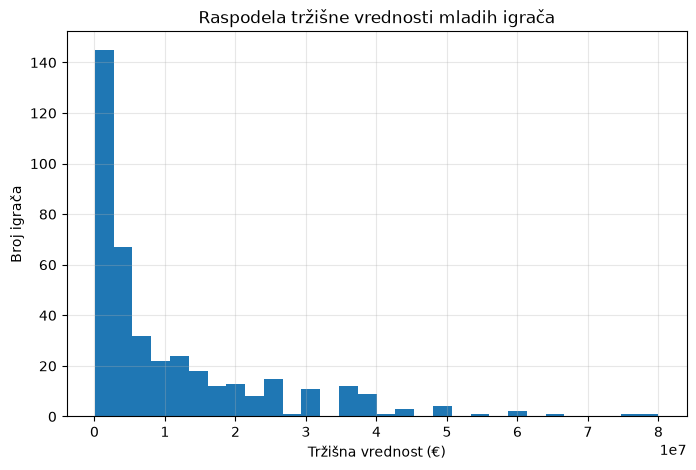

In [98]:
plt.figure(figsize=(8,5))

plt.hist(
    young_players["market_value_in_eur"],
    bins=30
)

plt.xlabel("Tržišna vrednost (€)")
plt.ylabel("Broj igrača")
plt.title("Raspodela tržišne vrednosti mladih igrača")

plt.grid(alpha=0.3)

plt.show()

In [99]:
young_players = young_players.sort_values(
    by=[
        "valuation_growth_pct",
        "starter_ratio",
        "total_minutes",
        "international_caps"
    ],
    ascending=False
)

In [101]:
young_players = young_players.merge(
    players[["player_id", "name"]],
    on="player_id",
    how="left"
)

In [102]:
young_players[
    [
        "name",
        "age",
        "market_value_in_eur",
        "highest_market_value_in_eur",
        "valuation_growth_pct",
        "starter_ratio",
        "matches_played",
        "total_minutes",
        "international_caps"
    ]
].head(20)

,name,age,market_value_in_eur,highest_market_value_in_eur,valuation_growth_pct,starter_ratio,matches_played,total_minutes,international_caps
0,Jesús Rodríguez,20.56,30000000.0,30000000.0,1199.000000,0.523810,54.0,3072.0,1.0
1,El Hadji Malick Diouf,21.45,28000000.0,28000000.0,1119.000000,0.794118,26.0,2187.0,17.0
2,Jérémy Jacquet,20.91,55000000.0,55000000.0,1099.000000,0.640000,37.0,2855.0,5.0
3,Givairo Read,20.03,25000000.0,25000000.0,999.000000,0.500000,51.0,3558.0,1.0
4,Anan Khalaili,21.77,18000000.0,18000000.0,719.000000,0.615385,71.0,5162.0,16.0
5,Valentín Barco,21.89,35000000.0,35000000.0,699.000000,0.635135,56.0,4118.0,1.0
6,Ruben van Bommel,21.86,12000000.0,12000000.0,479.000000,0.658228,75.0,4375.0,16.0
7,Michael Kayode,21.92,35000000.0,35000000.0,465.666667,0.421053,87.0,6205.0,9.0
8,Jaydee Canvot,19.87,20000000.0,20000000.0,399.000000,0.600000,37.0,2259.0,6.0
9,Matvey Kislyak,20.88,20000000.0,20000000.0,399.000000,0.395349,75.0,5533.0,8.0


Kao i kod golmana, ovim postupkom smo dosli do skupa mladih igraca koji svi mogu predstaviti dobru investiciju za klub, a na konkretnom klubu je zadatak da na osnovu svoje taktike, budzeta i ostalih zahteva odredi koji od njih je prava meta za transfer.
Nadalje, radicemo nesto slicno kao i za golmane, samo za igrace, a konkretno u poslednjem klasteru koji se sastoji od elitnih igraca.

### Elitni, afirmisani igraci

In [103]:
elite_players = analysis[
    analysis["cluster"] == 2
].copy()

elite_players.shape

(6456, 99)

In [113]:
elite_players = elite_players[
    (elite_players["market_value_in_eur"] > 0) &
    (elite_players["matches_played"] >= 30) &
    (elite_players["total_minutes"] >= 2000) &
    (elite_players["age"] <= 30) 
].copy()

elite_players.shape

(1947, 99)

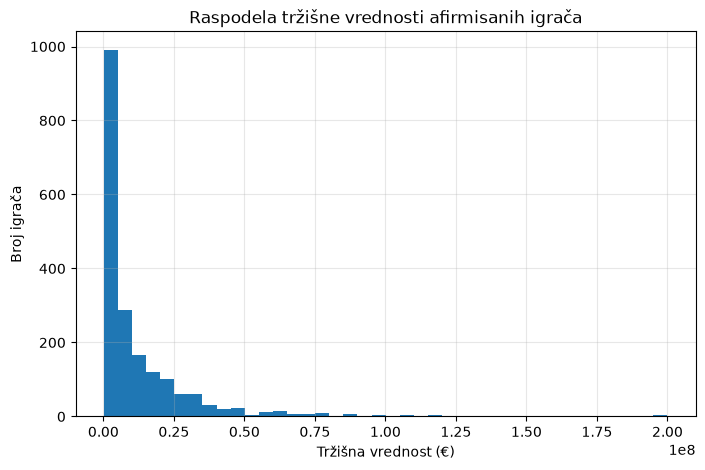

In [114]:
plt.figure(figsize=(8,5))

plt.hist(
    elite_players["market_value_in_eur"],
    bins=40
)

plt.xlabel("Tržišna vrednost (€)")
plt.ylabel("Broj igrača")
plt.title("Raspodela tržišne vrednosti afirmisanih igrača")

plt.grid(alpha=0.3)

plt.show()

Buduci da se radi o afirmisanim igracima, odnosno onima koji su vec dovoljno poznati i potvrdjeno dobri igraci, zapravo cemo gledati samo one igrace koji se nalaze u prvom i drugom kvartilu po njihovoj trzisnoj vrednosti. U tom skupu cemo pokusati da izlistamo opcije koje mogu predstavljati odlicne investicije (za igrace koji se nalaze u ostatku skupa je uglavnom jasno da bi investicija u njih bila odlicna za bilo koji klub, ali zelimo da se fokusiramo na ne tako standardne opcije koje mozda mogu biti zanemarene)

In [115]:
q2 = elite_players["market_value_in_eur"].quantile(0.5)

print(f"Q2 = {q2:,.0f} €")

Q2 = 5,000,000 €


In [116]:
vfm_elite = elite_players[
    elite_players["market_value_in_eur"] <= q2
].copy()

vfm_elite.shape

(991, 99)

In [117]:
vfm_elite = vfm_elite.sort_values(
    by=[
        "international_caps",
        "starter_ratio",
        "total_minutes",
        "valuation_growth_pct"
    ],
    ascending=False
)

In [118]:
vfm_elite = vfm_elite.merge(
    players[["player_id", "name"]],
    on="player_id",
    how="left"
)

In [119]:
vfm_elite[
    [
        "name",
        "age",
        "position",
        "market_value_in_eur",
        "highest_market_value_in_eur",
        "international_caps",
        "matches_played",
        "total_minutes",
        "starter_ratio",
        "valuation_growth_pct"
    ]
].head(20)

,name,age,position,market_value_in_eur,highest_market_value_in_eur,international_caps,matches_played,total_minutes,starter_ratio,valuation_growth_pct
0,Otabek Shukurov,29.97,Midfield,1600000.0,4000000.0,85.0,55.0,3025.0,0.696203,4.818182
1,Christopher Martins,29.31,Midfield,4500000.0,6000000.0,80.0,144.0,8643.0,0.610294,44.000000
2,Grigoris Kastanos,28.36,Midfield,1800000.0,1800000.0,76.0,126.0,5612.0,0.357542,23.000000
3,Danel Sinani,29.19,Midfield,3000000.0,3000000.0,71.0,75.0,4404.0,0.520408,119.000000
4,José Luis Rodríguez,27.98,Attack,2500000.0,2500000.0,66.0,32.0,2122.0,0.640000,24.000000
5,Milot Rashica,29.95,Attack,4000000.0,35000000.0,63.0,350.0,24274.0,0.785100,79.000000
6,Oleg Reabciuk,28.40,Defender,3000000.0,5000000.0,62.0,207.0,15826.0,0.752252,119.000000
7,Shamar Nicholson,29.24,Attack,3200000.0,7500000.0,62.0,164.0,9335.0,0.557895,63.000000
8,Mostafa Mohamed,28.54,Attack,4000000.0,10000000.0,61.0,185.0,9418.0,0.502564,159.000000
9,Kelechi Iheanacho,29.69,Attack,3000000.0,20000000.0,58.0,264.0,11324.0,0.323944,29.000000
